# DMASS algorithm tutorial

In [159]:
import os, sys
import esutil
import healpy as hp
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt

import fitsio
from astroML.crossmatch import crossmatch_angular
import numpy.lib.recfunctions as rf

# call required functions from modules 
sys.path.append('../code/')
from xd import XD_fitting_X, doVisualization_1d, assignCMASSProb

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load DES and CMASS data

The DMASS algorithm learns what CMASS galaxies look like in DES photometry. We start in the small patch of sky where BOSS and DES overlap (Stripe 82), where we already know which DES galaxies are CMASS. Here we load the DES Y3 Gold catalog for that region and will later split it into a CMASS group and a non-CMASS group.

In [141]:
gold_st82_full=fitsio.read('/fs/ess/PHS0411/summer/desy3gold_stripe82.fits', upper=True)

## Filtering catalogs

Real catalogs contain junk: bad photometry, flagged regions, and stars masquerading as galaxies. Before training on anything, we keep only clean galaxies (`FLAGS` cuts), drop objects with extreme magnitudes/colors, and remove stars using the `EXTENDED_CLASS_MASH_SOF` classifier. We keep a clean star sample separately. It's useful later for seeing how stars and galaxies separate in color space.

In [143]:
def filtering(data):

    # select only clean region
    clean_cut = (data['FLAGS_FOOTPRINT'] == 1) & (data['FLAGS_GOLD'] == 0)

    # cutting out extreme mags and colors 
    mag_g = data['MOF_CM_MAG_CORRECTED_G']
    mag_r = data['MOF_CM_MAG_CORRECTED_R']
    mag_i = data['MOF_CM_MAG_CORRECTED_I']
    mag_z = data['MOF_CM_MAG_CORRECTED_Z']
    color_gr = data['MOF_CM_MAG_CORRECTED_G'] - data['MOF_CM_MAG_CORRECTED_R']
    color_ri = data['MOF_CM_MAG_CORRECTED_R'] - data['MOF_CM_MAG_CORRECTED_I']
    color_iz = data['MOF_CM_MAG_CORRECTED_I'] - data['MOF_CM_MAG_CORRECTED_Z']

    cut = (((mag_g > 15) & (mag_g <30)) &
           ((mag_r > 15) & (mag_r <30)) &
           ((mag_i > 15) & (mag_i <23)) &
           ((mag_z > 15) & (mag_z <30)) &
           ((color_gr) <  3.0 ) & 
           ((color_gr) >  0.0 ) & 
           ((color_ri) <  3.0 ) & 
           ((color_ri) >  0.0 ) &
           ((color_iz) <  3.0 ) & 
           ((color_iz) >  0.0 ) 
        )
    return data[clean_cut & cut]

def discard_stars(data):
    # select only galaxies 
    return data[data['EXTENDED_CLASS_MASH_SOF'] == 3]
# ------------------------------------------------

print ('Number of total objects in the DES GOLD catalg: ', len(gold_st82_full))
gold_st82_galaxies = discard_stars(gold_st82_full)
print('Number of galaxies in the DES GOLD catalog: ', len(gold_st82_galaxies))

# high confidence stars & bright stars 
gold_st82_stars = gold_st82_full[(gold_st82_full['EXTENDED_CLASS_MASH_SOF'] == 0) & (gold_st82_full['MOF_CM_MAG_CORRECTED_I'] < 20.0)]

# filter out extreme outliers 
gold_st82 = filtering(gold_st82_galaxies)
print('Number of galaxies in the filtered catalog: ', len(gold_st82))
# free memory
gold_st82_full = gold_st82_galaxies = None

Number of total objects in the DES GOLD catalg:  14604462
Number of galaxies in the DES GOLD catalog:  9268420
Number of galaxies in the filtered catalog:  4951372


# Investigate DES catalogs

Now we load the BOSS CMASS catalog and plot both footprints together. Notice CMASS only covers part of the DES area. That gap is exactly the problem DMASS exists to fill.

In [144]:
# cmass catalog is stored in cosmos machine
cmass_filename = '/fs/ess/PHS0411/summer/galaxy_DR12v5_CMASS_South.fits.gz'
cmass = esutil.io.read(cmass_filename)

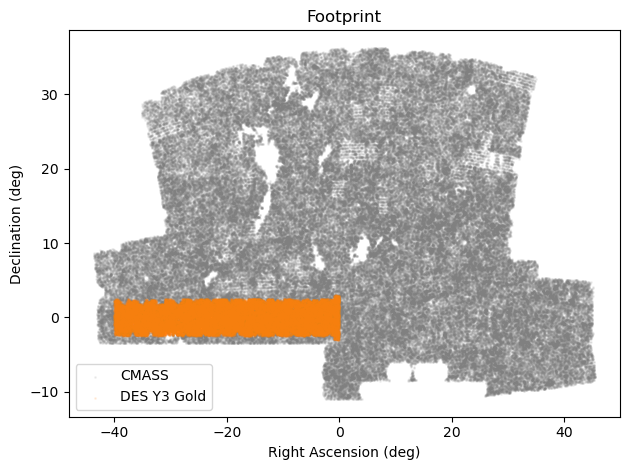

In [145]:
fig, ax = plt.subplots()

ra_plot = np.where(cmass['RA'] > 180, cmass['RA'] - 360, cmass['RA'])
ra_plot_des = np.where(gold_st82['RA'] > 180, gold_st82['RA'] - 360, gold_st82['RA'])

ax.scatter( ra_plot, cmass['DEC'],  color='gray', s=1, alpha=0.1, label='CMASS', rasterized=True)
ax.scatter( ra_plot_des[::100], gold_st82['DEC'][::100], color='tab:orange', s=1, alpha = 0.1, label='DES Y3 Gold', rasterized=True)

ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('Footprint')
ax.legend()
#ax.set_xlim(300, 360)
plt.tight_layout()
plt.show()



# Cross matching catalogs

A galaxy observed by both surveys appears in both catalogs at (almost) the same sky position. By matching positions within 2 arcsec, we can flag which DES galaxies are CMASS. This gives us our two labeled groups (CMASS and non-CMASS) which are the "answers" the algorithm trains on. (Note: we're matching by position only; we're not using CMASS redshifts here.)

In [146]:
# stack RA/DEC 
Coord_CMASS = np.column_stack(( cmass['RA'], cmass['DEC'] ))
Coord_DES = np.column_stack(( gold_st82['RA'], gold_st82['DEC'] ))

# match positions of galaxies within 2 arcsec 
dist, idx = crossmatch_angular( Coord_DES, Coord_CMASS, max_distance=2/3600 )
select_cmass = ~np.isinf(dist) # mask for selecting CMASS galaxies in the DES catalg 

# cmass galaxies in the DES catalog 
cmass_in_des = gold_st82[select_cmass]
nocmass = gold_st82[~select_cmass]
print (f"Number of common galaxies in CMASS and Y3 GOLD catalogs: {cmass_in_des.size}")
print (f"Number of non-CMASS galaxies in Y3 GOLD catalog: {nocmass.size}")

Number of common galaxies in CMASS and Y3 GOLD catalogs: 16390
Number of non-CMASS galaxies in Y3 GOLD catalog: 4934982


# Let's take a look at objects in the DES catalog

Before training, it's worth looking at where DES and CMASS galaxies actually live in color space. The plots below show the key idea behind the whole method: CMASS galaxies occupy a fairly specific region of the color-color diagram, distinct from stars and from typical field galaxies. That separation is what makes a color-based selection possible.

### We first define colors and magnitude to use 

In [147]:
# define magnitude and colors 

# galaxies 
mag_g = gold_st82['MOF_CM_MAG_CORRECTED_G']
mag_r = gold_st82['MOF_CM_MAG_CORRECTED_R']
mag_i = gold_st82['MOF_CM_MAG_CORRECTED_I']
mag_z = gold_st82['MOF_CM_MAG_CORRECTED_Z']

color_gr = mag_g-mag_r
color_ri = mag_r-mag_i 
color_iz = mag_i-mag_z 


# stars 
color_gr_star = gold_st82_stars['MOF_CM_MAG_CORRECTED_G'] - gold_st82_stars['MOF_CM_MAG_CORRECTED_R']
color_ri_star = gold_st82_stars['MOF_CM_MAG_CORRECTED_R'] - gold_st82_stars['MOF_CM_MAG_CORRECTED_I']

### Galaxies and Stars in the Color-Color diagram

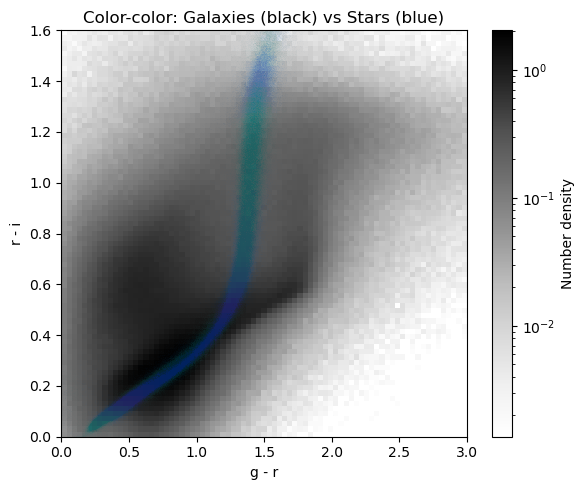

In [148]:
from matplotlib.colors import LogNorm

gr_bins = np.linspace(0.0, 3.0, 80)
ri_bins = np.linspace(0.0, 1.6, 80)

fig, ax = plt.subplots(figsize=(6, 5))

# sample1: filled 2D histogram (density)
H1, xe, ye = np.histogram2d(color_gr[mag_i >19], color_ri[mag_i > 19], bins=[gr_bins, ri_bins], density=True)
#H1, xe, ye = np.histogram2d(color_gr[(mag_i < 1) & (color_gr > 1.0)], color_ri[(mag_i < 1) & (color_gr > 1.0)], bins=[gr_bins, ri_bins], density=True)
vmin = np.percentile(H1[H1 > 0], 5)
vmax = H1.max()
pcm = ax.pcolormesh(xe, ye, H1.T, cmap='Greys', norm=LogNorm(vmin=vmin, vmax=vmax), shading='auto')
fig.colorbar(pcm, ax=ax, label='Number density')

ax.scatter(color_gr_star, color_ri_star, s=1, color='tab:blue', alpha=0.01, linewidths=0, rasterized=True)

ax.set_ylim(0, 1.6)
ax.set_xlim(0, 3)
ax.set_xlabel('g - r')
ax.set_ylabel('r - i')
ax.set_title('Color-color: Galaxies (black) vs Stars (blue)')
plt.tight_layout()

#### Now add CMASS galaxies 

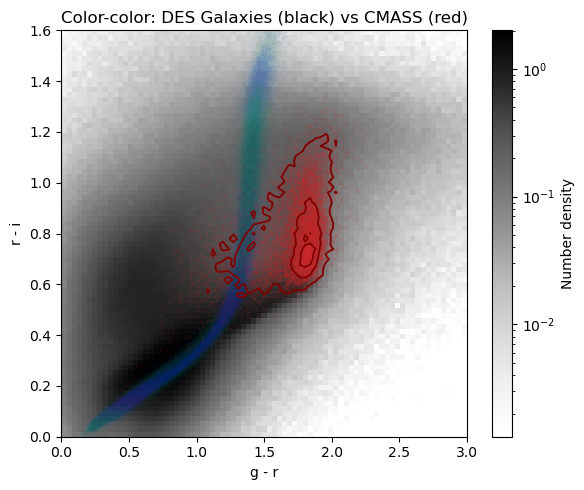

In [149]:
from matplotlib.colors import LogNorm

gr_bins = np.linspace(0.0, 3.0, 80)
ri_bins = np.linspace(0.0, 1.6, 80)

fig, ax = plt.subplots(figsize=(6, 5))

# sample1: filled 2D histogram (density)
H1, xe, ye = np.histogram2d(color_gr, color_ri, bins=[gr_bins, ri_bins], density=True)
vmin = np.percentile(H1[H1 > 0], 5)
vmax = H1.max()
pcm = ax.pcolormesh(xe, ye, H1.T, cmap='Greys', norm=LogNorm(vmin=vmin, vmax=vmax), shading='auto')
fig.colorbar(pcm, ax=ax, label='Number density')

# sample2: contour overlay
H2, xe2, ye2 = np.histogram2d(color_gr[select_cmass], color_ri[select_cmass],  bins=[gr_bins, ri_bins], density=False)
xc = 0.5 * (xe[:-1] + xe[1:])
yc = 0.5 * (ye[:-1] + ye[1:])
levels = np.percentile(H2[H2 > 0], [68, 95, 99])   # contour level
ax.contour(xc, yc, H2.T, levels=levels, colors='maroon', linewidths=1.3)

ax.scatter(color_gr[select_cmass], color_ri[select_cmass], s=3, color='tab:red', alpha=0.1, linewidths=0, rasterized=True)


color_gr_star = gold_st82_stars['MOF_CM_MAG_CORRECTED_G'] - gold_st82_stars['MOF_CM_MAG_CORRECTED_R']
color_ri_star = gold_st82_stars['MOF_CM_MAG_CORRECTED_R'] - gold_st82_stars['MOF_CM_MAG_CORRECTED_I']
ax.scatter(color_gr_star, color_ri_star, s=1, color='tab:blue', alpha=0.01, linewidths=0, rasterized=True)

#pcm = ax.pcolormesh(xe2, ye2, H2.T, cmap='Reds', shading='auto')
#fig.colorbar(pcm, ax=ax, label='Number density')

ax.set_ylim(0, 1.6)
ax.set_xlim(0, 3)
ax.set_xlabel('g - r')
ax.set_ylabel('r - i')
ax.set_title('Color-color: DES Galaxies (black) vs CMASS (red)')
plt.tight_layout()

#### Let's look into other color-color diagram too 

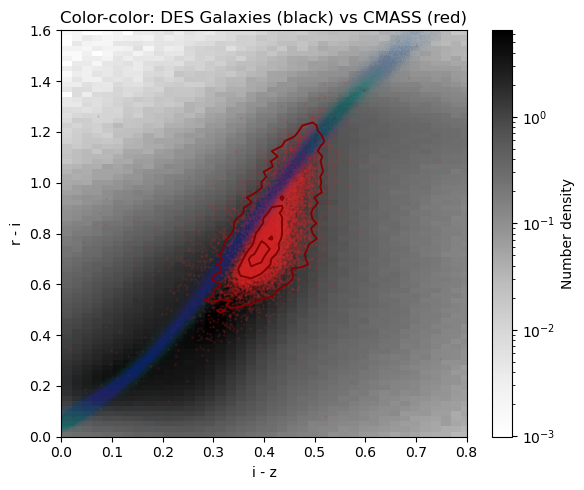

In [150]:
from matplotlib.colors import LogNorm

iz_bins = np.linspace(0.0, 1.6, 80)
ri_bins = np.linspace(0.0, 1.6, 80)

fig, ax = plt.subplots(figsize=(6, 5))

# sample1: filled 2D histogram (density)
H1, xe, ye = np.histogram2d(color_iz, color_ri, bins=[iz_bins, ri_bins], density=True)
vmin = np.percentile(H1[H1 > 0], 5)
vmax = H1.max()
pcm = ax.pcolormesh(xe, ye, H1.T, cmap='Greys', norm=LogNorm(vmin=vmin, vmax=vmax), shading='auto')
fig.colorbar(pcm, ax=ax, label='Number density')

# sample2: contour overlay (같은 bin)
H2, xe2, ye2 = np.histogram2d(color_iz[select_cmass], color_ri[select_cmass],  bins=[iz_bins, ri_bins], density=False)
xc = 0.5 * (xe[:-1] + xe[1:])
yc = 0.5 * (ye[:-1] + ye[1:])
levels = np.percentile(H2[H2 > 0], [68, 95, 99])   # contour level
ax.contour(xc, yc, H2.T, levels=levels, colors='maroon', linewidths=1.3)

ax.scatter(color_iz[select_cmass], color_ri[select_cmass], s=3, color='tab:red', alpha=0.2, linewidths=0, rasterized=True)

#pcm = ax.pcolormesh(xe2, ye2, H2.T, cmap='Reds', shading='auto')
#fig.colorbar(pcm, ax=ax, label='Number density')

color_iz_star = gold_st82_stars['MOF_CM_MAG_CORRECTED_I'] - gold_st82_stars['MOF_CM_MAG_CORRECTED_Z']
color_ri_star = gold_st82_stars['MOF_CM_MAG_CORRECTED_R'] - gold_st82_stars['MOF_CM_MAG_CORRECTED_I']
ax.scatter(color_iz_star, color_ri_star, s=1, color='tab:blue', alpha=0.01, linewidths=0, rasterized=True)

ax.set_ylim(0, 1.6)
ax.set_xlim(0, 0.8)
ax.set_xlabel('i - z')
ax.set_ylabel('r - i')
ax.set_title('Color-color: DES Galaxies (black) vs CMASS (red)')
plt.tight_layout()

#### Also check magnitudes and 1D color distributions 

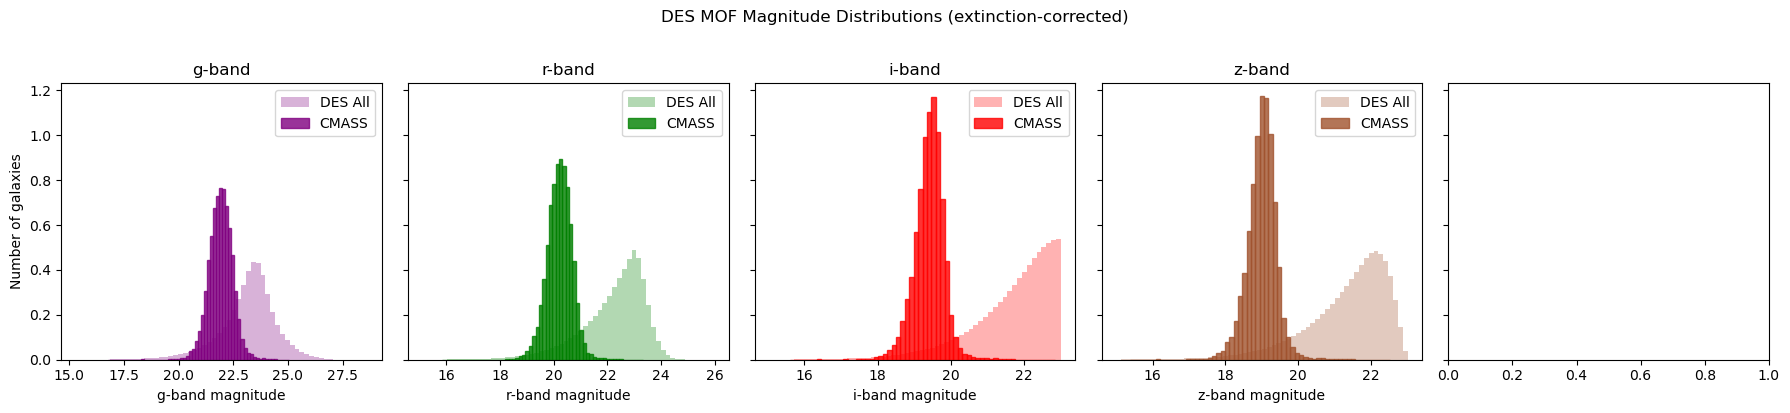

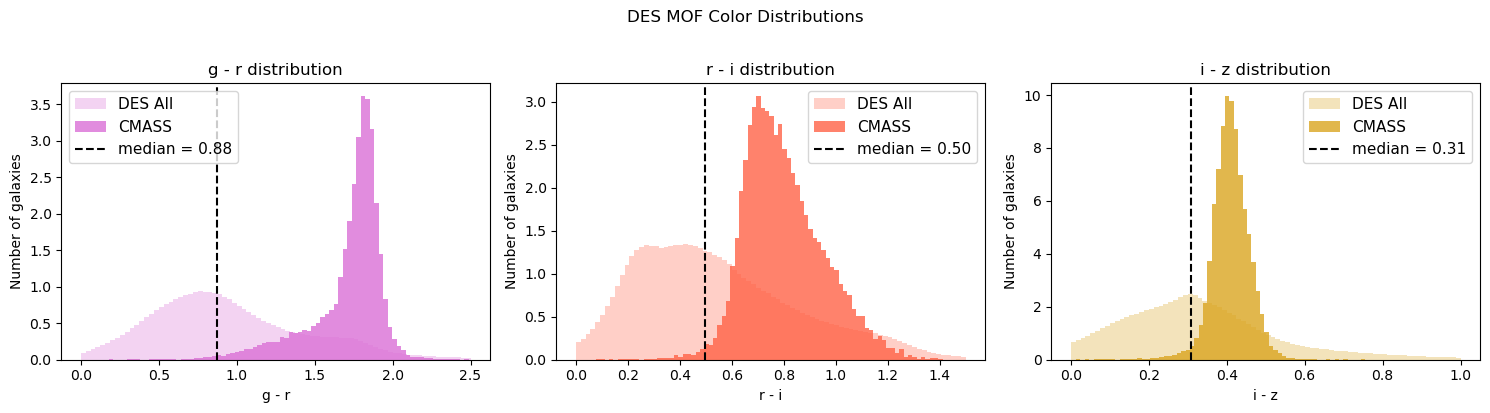

In [151]:

bands  = ['g', 'r', 'i', 'z']
mags   = [mag_g, mag_r, mag_i, mag_z]
colors = ['purple', 'green', 'red', 'sienna', 'gray']

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, band, m, c in zip(axes, bands, mags, colors):
    # Only plot galaxies with reasonable magnitudes
    mask = (m > 10) & (m < 30)
    ax.hist(m[mask], bins=60, color=c, alpha=0.3, edgecolor='none', density=True, label='DES All')
    ax.hist(m[mask & select_cmass], bins=60, color=c, alpha=0.8, edgecolor=c, density=True, label='CMASS')
    ax.set_xlabel(f'{band}-band magnitude')
    ax.set_title(f'{band}-band')
    ax.legend()

axes[0].set_ylabel('Number of galaxies')
fig.suptitle('DES MOF Magnitude Distributions (extinction-corrected)', y=1.02)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

color_data = [color_gr, color_ri, color_iz]
color_names = ['g - r', 'r - i', 'i - z']
xlims = [(-0.5, 2.5), (-0.5, 1.5), (-0.5, 1.0)]
plot_colors = ['orchid', 'tomato', 'goldenrod']

for ax, c, name, xlim, pc in zip(axes, color_data, color_names, xlims, plot_colors):
    mask = np.isfinite(c) & (c > xlim[0]) & (c < xlim[1])
    ax.hist(c[mask], bins=80, color=pc, alpha=0.3, edgecolor='none', density=True, label='DES All')
    ax.hist(c[mask & select_cmass], bins=80, color=pc, alpha=0.8, edgecolor='none', density=True, label='CMASS')
    ax.set_xlabel(name)
    ax.set_ylabel('Number of galaxies')
    ax.set_title(f'{name} distribution')
    ax.axvline(np.median(c[mask]), color='k', linestyle='--', linewidth=1.5, label=f'median = {np.median(c[mask]):.2f}')
    ax.legend(fontsize=11)

fig.suptitle('DES MOF Color Distributions', y=1.02)
plt.tight_layout()
plt.show()

#### You can use other colors and magnitudes 

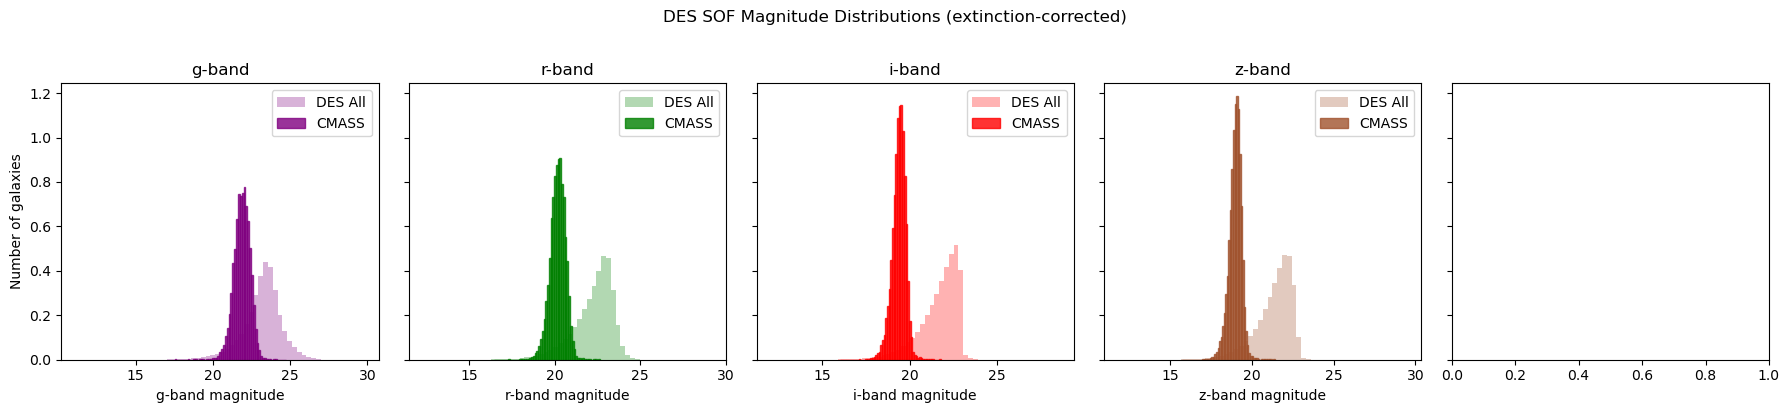

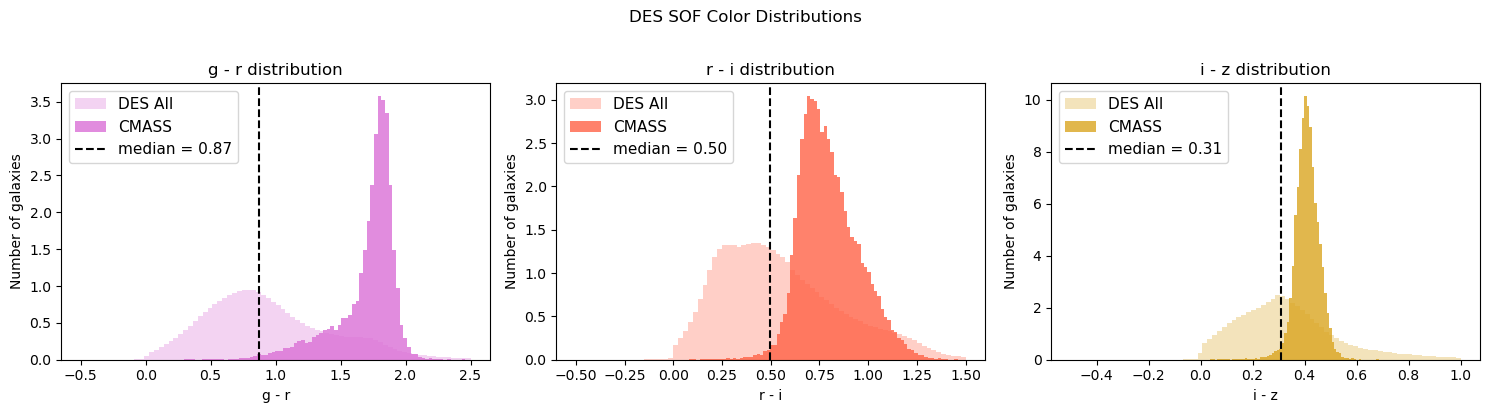

In [152]:
# Use SOF_CM_MAG instead of MOF_CM_MAG

mag_g = gold_st82['SOF_CM_MAG_CORRECTED_G']
mag_r = gold_st82['SOF_CM_MAG_CORRECTED_R']
mag_i = gold_st82['SOF_CM_MAG_CORRECTED_I']
mag_z = gold_st82['SOF_CM_MAG_CORRECTED_Z']
color_gr = mag_g-mag_r
color_ri = mag_r-mag_i 
color_iz = mag_i-mag_z 

bands  = ['g', 'r', 'i', 'z']
mags   = [mag_g, mag_r, mag_i, mag_z]
colors = ['purple', 'green', 'red', 'sienna', 'gray']

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, band, m, c in zip(axes, bands, mags, colors):
    # Only plot galaxies with reasonable magnitudes
    mask = (m > 10) & (m < 30)
    ax.hist(m[mask], bins=60, color=c, alpha=0.3, edgecolor='none', density=True, label='DES All')
    ax.hist(m[mask & select_cmass], bins=60, color=c, alpha=0.8, edgecolor=c, density=True, label='CMASS')
    ax.set_xlabel(f'{band}-band magnitude')
    ax.set_title(f'{band}-band')
    ax.legend()

axes[0].set_ylabel('Number of galaxies')
fig.suptitle('DES SOF Magnitude Distributions (extinction-corrected)', y=1.02)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

color_data = [color_gr, color_ri, color_iz]
color_names = ['g - r', 'r - i', 'i - z']
xlims = [(-0.5, 2.5), (-0.5, 1.5), (-0.5, 1.0)]
plot_colors = ['orchid', 'tomato', 'goldenrod']

for ax, c, name, xlim, pc in zip(axes, color_data, color_names, xlims, plot_colors):
    mask = np.isfinite(c) & (c > xlim[0]) & (c < xlim[1])
    ax.hist(c[mask], bins=80, color=pc, alpha=0.3, edgecolor='none', density=True, label='DES All')
    ax.hist(c[mask & select_cmass], bins=80, color=pc, alpha=0.8, edgecolor='none', density=True, label='CMASS')
    ax.set_xlabel(name)
    ax.set_ylabel('Number of galaxies')
    ax.set_title(f'{name} distribution')
    ax.axvline(np.median(c[mask]), color='k', linestyle='--', linewidth=1.5, label=f'median = {np.median(c[mask]):.2f}')
    ax.legend(fontsize=11)

fig.suptitle('DES SOF Color Distributions', y=1.02)
plt.tight_layout()
plt.show()

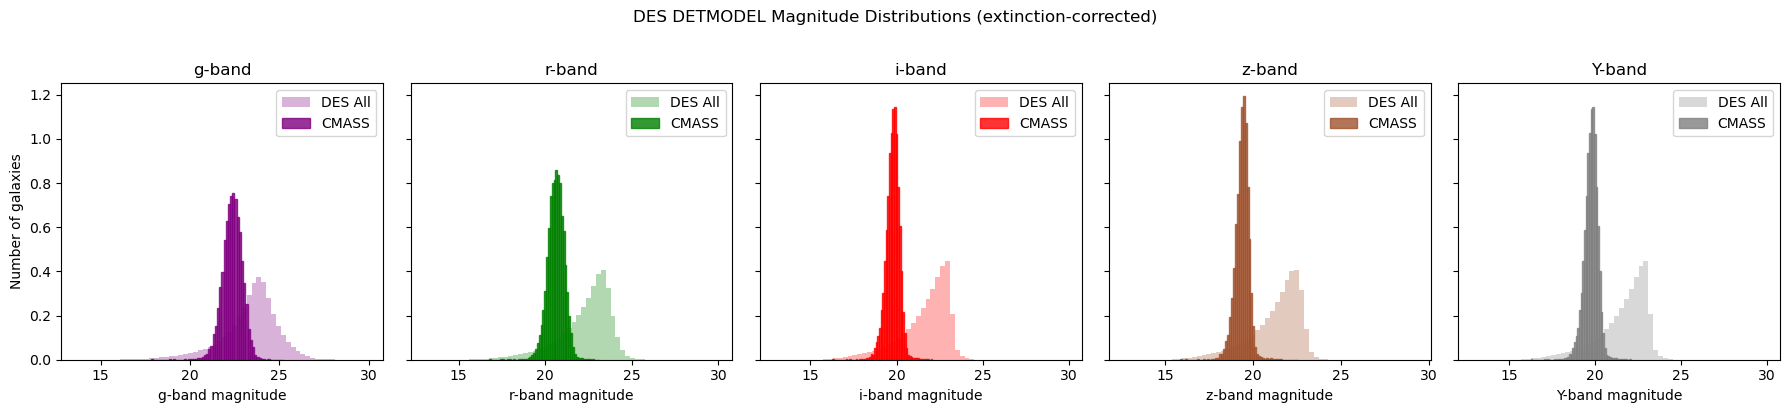

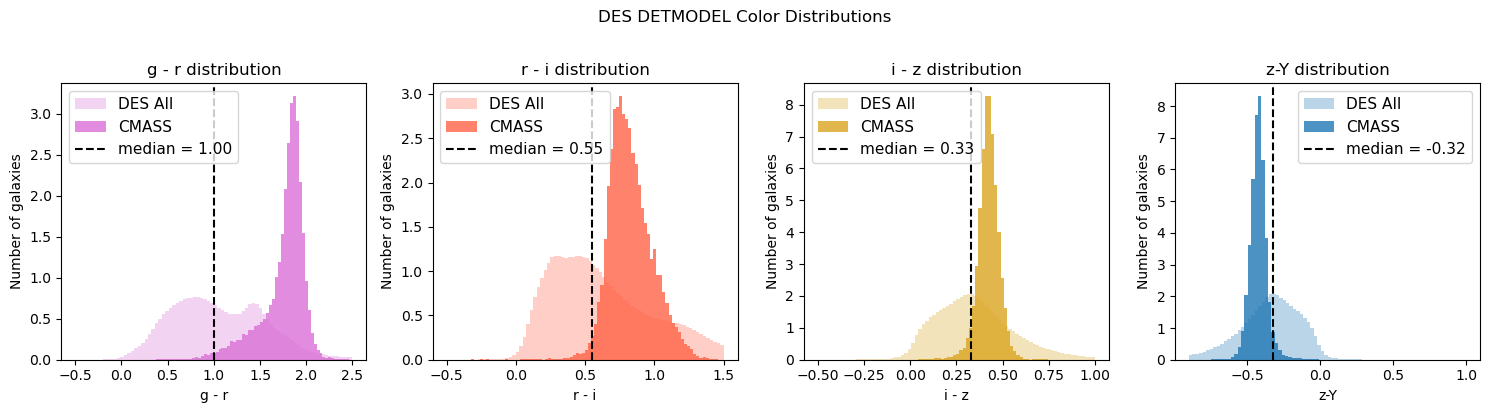

In [ ]:
mag_g = gold_st82['MAG_DETMODEL_G']
mag_r = gold_st82['MAG_DETMODEL_R']
mag_i = gold_st82['MAG_DETMODEL_I']
mag_z = gold_st82['MAG_DETMODEL_Z']
mag_y = gold_st82['MAG_DETMODEL_I']
color_gr = mag_g-mag_r
color_ri = mag_r-mag_i 
color_iz = mag_i-mag_z 
color_zy = mag_z-mag_y 

bands  = ['g', 'r', 'i', 'z', 'Y']
mags   = [mag_g, mag_r, mag_i, mag_z, mag_y]
colors = ['purple', 'green', 'red', 'sienna', 'gray']

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, band, m, c in zip(axes, bands, mags, colors):
    # Only plot galaxies with reasonable magnitudes
    mask = (m > 10) & (m < 30)
    ax.hist(m[mask], bins=60, color=c, alpha=0.3, edgecolor='none', density=True, label='DES All')
    ax.hist(m[mask & select_cmass], bins=60, color=c, alpha=0.8, edgecolor=c, density=True, label='CMASS')
    ax.set_xlabel(f'{band}-band magnitude')
    ax.set_title(f'{band}-band')
    ax.legend()

axes[0].set_ylabel('Number of galaxies')
fig.suptitle('DES DETMODEL Magnitude Distributions (extinction-corrected)', y=1.02)

plt.tight_layout()
plt.show()




fig, axes = plt.subplots(1, 4, figsize=(15, 4))

color_data = [color_gr, color_ri, color_iz, color_zy]
color_names = ['g - r', 'r - i', 'i - z', 'z-Y']
xlims = [(-0.5, 2.5), (-0.5, 1.5), (-0.5, 1.0), (-0.9, 1.0)]
plot_colors = ['orchid', 'tomato', 'goldenrod', 'tab:blue']

for ax, c, name, xlim, pc in zip(axes, color_data, color_names, xlims, plot_colors):
    mask = np.isfinite(c) & (c > xlim[0]) & (c < xlim[1])
    ax.hist(c[mask], bins=80, color=pc, alpha=0.3, edgecolor='none', density=True, label='DES All')
    ax.hist(c[mask & select_cmass], bins=80, color=pc, alpha=0.8, edgecolor='none', density=True, label='CMASS')
    ax.set_xlabel(name)
    ax.set_ylabel('Number of galaxies')
    ax.set_title(f'{name} distribution')
    ax.axvline(np.median(c[mask]), color='k', linestyle='--', linewidth=1.5, label=f'median = {np.median(c[mask]):.2f}')
    ax.legend(fontsize=11)

fig.suptitle('DES DETMODEL Color Distributions', y=1.02)
plt.tight_layout()
plt.show()

## Now let's run the DMASS algorithm

Here's the core idea. Extreme Deconvolution (XD) fits the underlying color distribution of a sample with a mixture of Gaussians, while accounting for each galaxy's measurement error, so it recovers the true distribution rather than the noise-broadened one. We'll fit one XD model to CMASS and one to non-CMASS. Then, for any new galaxy, we can ask how well it matches each model. The $W$ matrix just converts magnitudes $(g, r, i, z)$ into the quantities we want to model $(g, g−r, r−i, i−z)$. Because colors are differences of magnitudes, the measurement errors get correlated — so we propagate the error covariance the same way: 
$$
C_{\rm color} = W C_{\rm mag} W^{T}
$$

### Construct Magnitudes and Color stacks for XD

Choose colors and magnitudes. I am using MOF mags 

In [153]:
# magnitude in DES. Choose magnitudes you want. You can also mix different types of magnitudes and colors 
# This manigutdes are already corrected for the galactic extinction 
mag_g = gold_st82['MOF_CM_MAG_CORRECTED_G']
mag_r = gold_st82['MOF_CM_MAG_CORRECTED_R']
mag_i = gold_st82['MOF_CM_MAG_CORRECTED_I']
mag_z = gold_st82['MOF_CM_MAG_CORRECTED_Z']
# magnitude error in DES 
errmag_g = gold_st82['MOF_CM_MAG_ERR_G']
errmag_r = gold_st82['MOF_CM_MAG_ERR_R']
errmag_i = gold_st82['MOF_CM_MAG_ERR_I']
errmag_z = gold_st82['MOF_CM_MAG_ERR_Z']

In [154]:

# stack data 
X = np.vstack([[mag_g, mag_r, mag_i, mag_z]]).T
Xerr = np.vstack([[errmag_g, errmag_r, errmag_i, errmag_z]]).T

# Mixing matrix W: maps (g, r, i, z) magnitudes -> (g, g-r, r-i, i-z)
# Depending on which magnitudes and colors you want to use, you need to change the mixing matrix. 
# how many features do you want to use? This determins M in the matrix (M x N)
W = np.array([[1, 0, 0, 0],    # g magnitude
              [1, -1, 0, 0],   # g-r color
              [0, 1, -1, 0],   # r-i color
              [0, 0, 1, -1]])  # i-z color

# transform each object's magnitudes into colors
X = np.dot(X, W.T)

# Build the diagonal magnitude-error covariance for every object (shape (N, 5, 5))
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2

# Propagate into color space: C_color = W C_mag W^T, applied to every object at once.
# (tensordot just does this matrix product for the whole stack.)
Xcov = np.tensordot(np.dot(Xcov, W.T), W, (-2, -1))

### Divide into training and test

We fit the model on one part of the sky (training) and apply it on a different part (test). Testing on unseen sky is how we check the model generalizes, rather than just memorizing the training galaxies.

In [155]:
# select data at 320 < deg < 330 as training sample
select_train = gold_st82['RA'] < 330 

# cmass in train region 
select_cmass_train = select_train & select_cmass
X_train = X[select_cmass_train]
Xcov_train = Xcov[select_cmass_train]

# cmass in test region 
select_cmass_test = (~select_train) & (select_cmass)
X_test = X[select_cmass_test]
Xcov_test = Xcov[select_cmass_test]


print (f"Number of CMASS galaxies in training sample: {len(X_train)}")
print (f"Number of CMASS galaxies in test sample: {len(X_test)}")

cmass_fraction = np.sum(select_cmass_train)/ sum(select_train & (~select_cmass))
print (f'fraction of CMASS galaxies in the training region: {cmass_fraction}')


Number of CMASS galaxies in training sample: 3656
Number of CMASS galaxies in test sample: 12734
fraction of CMASS galaxies in the training region: 0.0031617600002767404


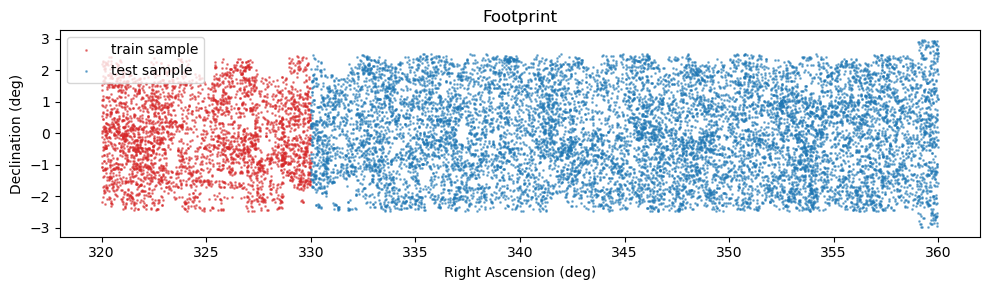

In [158]:
fig, ax = plt.subplots(figsize=(10,3))
ax.scatter( gold_st82['RA'][select_cmass_train], gold_st82['DEC'][select_cmass_train], color='tab:red', s=1, alpha = 0.5, label='train sample', rasterized=True)
ax.scatter( gold_st82['RA'][select_cmass_test], gold_st82['DEC'][select_cmass_test], color='tab:blue', s=1, alpha = 0.5, label='test sample', rasterized=True)

ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('Footprint')
ax.legend()
plt.tight_layout()
plt.show()

### Training XD for CMASS galaxies 

We fit the CMASS color distribution. Setting the number of Gaussians to None lets the algorithm pick it; `n_iter` is kept small here for speed, but a real run needs many more iterations to converge. The plot afterward compares galaxies drawn from the fitted model against the real training sample — if they overlap, the model captured the distribution well.

In [ ]:
# number of gaussian mixtures
# Set None for a initial run. The algorithm automatically finds an optimal number
n_cmass = None    # for cmass
# number of XD iteration. 
# I set these numbers small for a fast run but generally
# should be run until the XD algorithm converges (more than 10000 iterations)
n_iter_cmass = 100
#n_iter_no = 1
# tolerance
tol = 1E-5

# Fitted parameters and covariance will be stored as a pickle
outdir = '../output/fitting/'
os.makedirs(outdir, exist_ok=True)
pickle_filename = outdir+'gauss_cmass.pkl'

clf = XD_fitting_X( X_train, Xcov_train, pickleFileName = pickle_filename, 
                       n_clusters = n_cmass, max_iter = n_iter_cmass, tol = tol, 
                       verbose = True, init_params= None)   

@pickle_results: computing results and saving to '../output/fitting/gauss_cmass.pkl'
@pickle_results: computing results and saving to '../output/fitting/gauss_cmass.pkl.n_cluster'
Finding optimal number of cluster : 100 % 
best fit converged: True  n_components =  4
n components = 4
tolerance = 1e-05


/users/PHS0411/sjlee/.conda/envs/dmass/lib/python3.10/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


1: log(L) = 9470.442529
    (1.6 sec)
2: log(L) = 9529.379083
    (1.6 sec)
3: log(L) = 9566.91476
    (1.6 sec)
4: log(L) = 9596.715588
    (1.6 sec)
5: log(L) = 9622.58429
    (1.6 sec)
6: log(L) = 9644.574135
    (1.7 sec)
7: log(L) = 9661.679201
    (1.6 sec)
8: log(L) = 9673.949533
    (1.6 sec)
9: log(L) = 9682.701041
    (1.6 sec)
10: log(L) = 9689.250653
    (1.7 sec)
elapsed time: 0.25 min,  total iteration 9                                 


In [160]:
# from trained model, draw random sample 
X_trained_model = clf.sample(200000) 

Model looks good! 

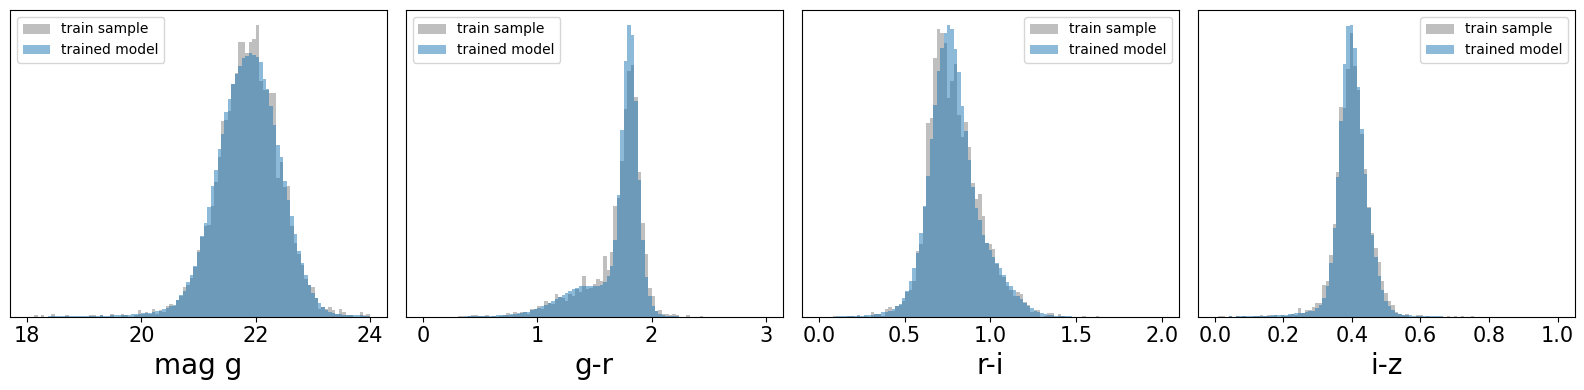

In [161]:
# Comparison. train vs. randoms from the fitted gaussian mixture model
doVisualization_1d( data=[X_train, X_trained_model], 
                   labels = ['mag g', 'g-r', 'r-i', 'i-z'], 
                   ranges = [[18,24], [0,3], [0,2], [0,1]], 
                   name = ['train sample', 'trained model'], 
                   weight = [None,None], 
                   nbins=100)

### Training for non-CMASS galaxies  

Same fit, but for everything that isn't CMASS. We subsample to keep it fast since this group is huge. We need both models because the decision is comparative: "does this galaxy look more like the CMASS distribution or the non-CMASS one?"

In [165]:

# To speed up the algorithm, we only use 1% of the sample
select_1percent = np.random.rand( len(X) ) < 0.05

# non-cmass in train region, only 1% 
select_nocmass_train_1percent = (select_train) & (~select_cmass) & select_1percent
X_nocmass_train = X[select_nocmass_train_1percent]
Xcov_nocmass_train = Xcov[select_nocmass_train_1percent]

# non-cmass in test region, only 1% 
select_nocmass_test_1percent = (~select_train) & (~select_cmass) & select_1percent
X_nocmass_test = X[select_nocmass_test_1percent]
Xcov_nocmass_test = Xcov[select_nocmass_test_1percent]


print (f"Number of non-CMASS galaxies in training sample: {len(X_nocmass_train)}")
print (f"Number of non-CMASS galaxies in test sample: {len(X_nocmass_test)}")

Number of non-CMASS galaxies in training sample: 99735
Number of non-CMASS galaxies in test sample: 254076


This will take a while! 

In [ ]:
# number of gaussian mixtures
# Set None for a initial run. The algorithm automatically finds an optimal number
#n_cmass = None    # for cmass
n_clusters = 20       # for non-cmass 
# number of XD iteration. 
# I set these numbers small for a fast run but generally
# should be run until the XD algorithm converges (more than 10000 iterations)
#n_iter_cmass = 10
max_iter = 100
# tolerance
tol = 1E-5

# Fitted parameters and covariance will be stored as a pickle
outdir = '../output/fitting/'
os.makedirs(outdir, exist_ok=True)
#cmass_pickle = outdir+'gauss_cmass.pkl'
pickle_filename = outdir+'gauss_nocmass.pkl'

clf_nocmass = XD_fitting_X( X_nocmass_train, Xcov_nocmass_train, pickleFileName = pickle_filename, 
                    n_clusters = n_clusters, max_iter = max_iter, tol = tol, 
                    verbose = True, init_params = None)

@pickle_results: computing results and saving to '../output/fitting/gauss_nocmass.pkl'
@pickle_results: computing results and saving to '../output/fitting/gauss_nocmass.pkl.n_cluster'
Finding optimal number of cluster : 58 % 

In [62]:
# from trained model, draw random sample 
X_trained_model = clf_nocmass.sample(200000) 

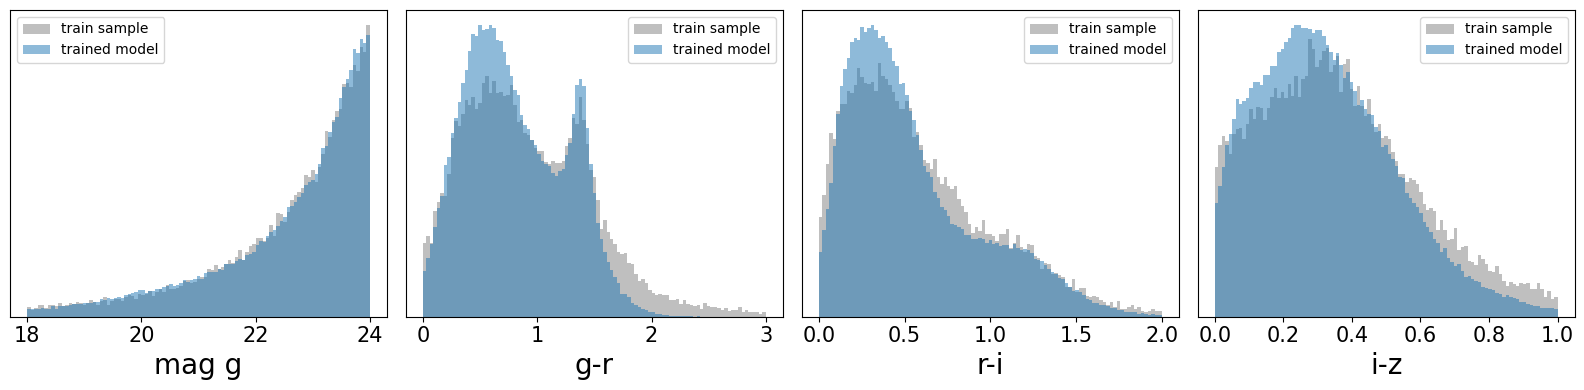

In [65]:
# Comparison. train vs. randoms from the fitted gaussian mixture model
doVisualization_1d( data=[X_nocmass_train, X_trained_model], 
                   labels = ['mag g', 'g-r', 'r-i', 'i-z'], 
                   ranges = [[18,24], [0,3], [0,2], [0,1]], 
                   name = ['train sample', 'trained model'], 
                   #weight = [None,None], 
                   nbins=100)

### Apply fitted model to the test data 

Now we combine the two models using Bayes' rule. For each galaxy in the test region, `assignCMASSProb_X` returns the probability it's CMASS: high if it sits where CMASS galaxies are dense and non-CMASS galaxies are sparse. The two distributions are first convolved with the test region's photometric errors so the comparison is fair.

In [ ]:
# To speed up the algorithm, we only choose the small region as a test region (Shouldn't be same with the training region)
select_region = (gold_st82['RA'] > 330) & (gold_st82['RA'] < 340)
select_test = (~select_train) & select_region

X_test_galaxies = X[select_test]
Xcov_test_galaxies = Xcov[select_test]

This will take a while 

In [76]:
from xd import assignCMASSProb_X
cmass_probability = assignCMASSProb_X(X_test_galaxies, Xcov_test_galaxies, clf, clf_nocmass, 
                     cmass_fraction = cmass_fraction)

calculate loglikelihood gaussian with multiprocessing module
multiprocessing 100 % 


### Now let's check the resulting CMASS probabilities

Text(0, 0.5, 'N')

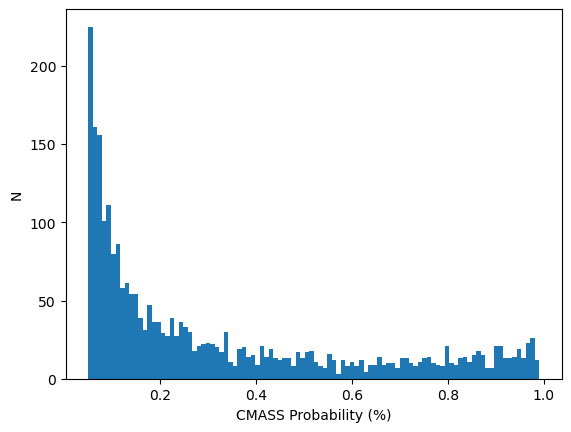

In [77]:
fig, ax = plt.subplots()
_ = ax.hist(cmass_probability[cmass_probability > 0.05], bins=100)
ax.set_xlabel('CMASS Probability (%)')
ax.set_ylabel('N')

Instead of a hard yes/no cut, every galaxy carries its CMASS probability as a weight. The weighted test sample below should reproduce the true CMASS color distribution. That's the payoff of the whole method.

How does the resulting sample look to you? It looks pretty similar with CMASS to me!

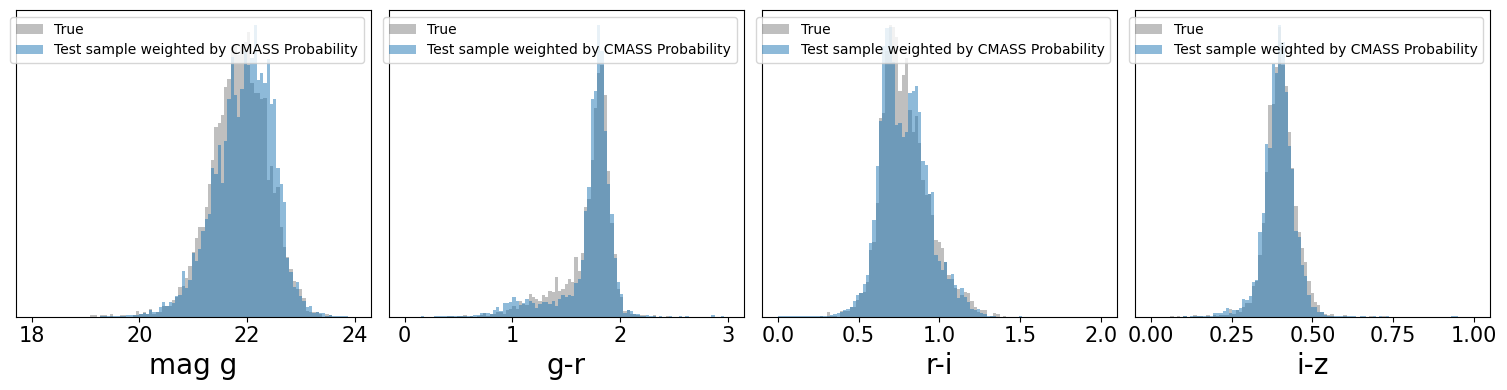

In [78]:
# Comparison. train vs. randoms from the fitted gaussian mixture model
doVisualization_1d(data=[X_train, X_test_galaxies], 
                   labels = ['mag g', 'g-r', 'r-i', 'i-z'], 
                   ranges = [[18,24], [0,3], [0,2], [0,1]], 
                   name = ['True', 'Test sample weighted by CMASS Probability'], 
                   # give probabilities as weights! 
                   weight = [None, cmass_probability], 
                   nbins=100)

### Save the result catalog

We attach the `CMASS_PROB` column and save. This weighted catalog is your starting DMASS sample. The input for the n(z) and w(θ) measurements in the rest of the project.

You will use this to compute the redshift distributions and correlation functions. 

In [ ]:
# Add the probability line to the test sample and same the catalog. 
result = gold_st82[select_test]
result = rf.append_fields(result, 'CMASS_PROB', cmass_probability)
# create output directory 
os.makedirs('../output/cat/', exist_ok=True)
# save catalog 
fitsio.write('../output/cat/test_ra330_340.fits', result)